<a href="https://colab.research.google.com/github/huamanchristian44/LAB-12/blob/develop/Laboratorio_12_Mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Laboratorio N°12: Modelos bayesianos**

In [1]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.7 MB/s eta 0:00:00


In [2]:
# Importando librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import category_encoders as ce

In [3]:
# Cargar datos
df = pd.read_csv('/content/drive/MyDrive/obesidad_file.csv')

In [4]:
# Ver primeras filas y tipos de datos
print(df.head())
print(df.info())

   Gender  Age  Height  Weight family_history_with_overweight FAVC  FCVC  NCP  \
0  Female   21    1.62    64.0                            yes   no     2    3   
1  Female   21    1.52    56.0                            yes   no     3    3   
2    Male   23    1.80    77.0                            yes   no     2    3   
3    Male   27    1.80    87.0                             no   no     3    3   
4    Male   22    1.78    89.8                             no   no     2    1   

        CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS  \
0  Sometimes    no     2   no    0    1          no  Public_Transportation   
1  Sometimes   yes     3  yes    3    0   Sometimes  Public_Transportation   
2  Sometimes    no     2   no    2    1  Frequently  Public_Transportation   
3  Sometimes    no     2   no    2    0  Frequently                Walking   
4  Sometimes    no     2   no    0    0   Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Wei

Se observa que no se presentan datos nulos

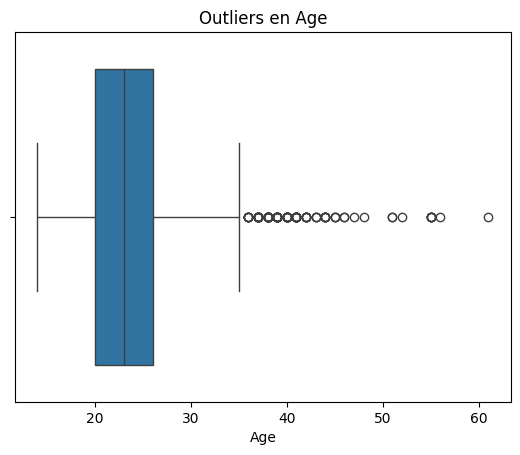

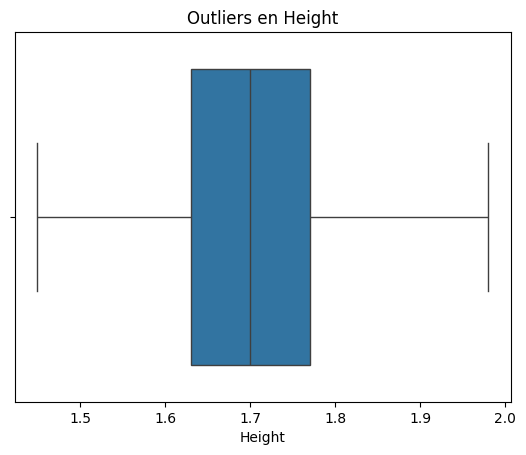

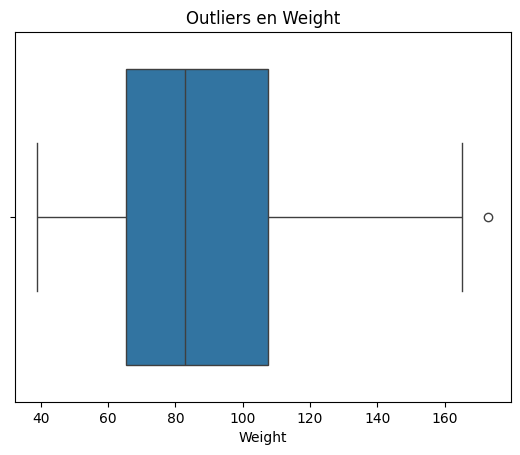

In [6]:
#Outliers univariados
numeric_cols = ['Age', 'Height', 'Weight']

# Boxplots
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Outliers en {col}')
    plt.show()

Se observa la presencia de valores atípicos cuando se toma en cuenta la variable edad. En este caso, se observa que la mayor concentración de las personas se encuentran entre los 20 hasta aproximadamente los 27 años. La altura mediana de los involucrados se encuentra entre los 1.7m. Sin embargo, la concentración de la altura oscila entre los 1.6 a 1.8m. Además, el peso mediano de la obesidad se encuentra cerca de los 80kg, lo cual significa que

In [7]:
#Winsorización
from scipy.stats.mstats import winsorize

for col in numeric_cols:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

In [8]:
#Outliers multivariados
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

data_num = df[numeric_cols]
cov_matrix = np.cov(data_num.T)
inv_cov_matrix = inv(cov_matrix)
mean_distr = data_num.mean().values

mahal_dist = data_num.apply(lambda x: mahalanobis(x, mean_distr, inv_cov_matrix), axis=1)
threshold = np.percentile(mahal_dist, 99)  # Top 1% as outliers

df = df[mahal_dist < threshold]

In [9]:
#Balanceo de clases
print(df['NObeyesdad'].value_counts())

NObeyesdad
Obesity_Type_I         344
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     288
Normal_Weight          285
Overweight_Level_II    279
Insufficient_Weight    272
Name: count, dtype: int64


In [10]:
# Empleo de SMOTE
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# Encoding temporal para balanceo
X_encoded = pd.get_dummies(X)

# SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_encoded, y)

# Verificamos nuevo balance
print(y_balanced.value_counts())

NObeyesdad
Normal_Weight          344
Overweight_Level_I     344
Overweight_Level_II    344
Obesity_Type_I         344
Insufficient_Weight    344
Obesity_Type_II        344
Obesity_Type_III       344
Name: count, dtype: int64


In [11]:
encoder = ce.OneHotEncoder(use_cat_names=True)
X_encoded = encoder.fit_transform(X)

In [12]:
#Naive Bayes
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

# MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
acc_mnb = accuracy_score(y_test, y_pred_mnb)

print(f'Accuracy GaussianNB: {acc_gnb:.4f}')
print(f'Accuracy MultinomialNB: {acc_mnb:.4f}')


Accuracy GaussianNB: 0.5000
Accuracy MultinomialNB: 0.6029
